# Demo 2

Convolutional Neural Network decoder for the rotated surface code

## Goals

Demonstrate how a decoder is built
Train the neural network on generated circuit data using stim
Simulate use of a decoder using sinter
Compare the custom built neural decoder against benchmark decoders on the rotated surface code
Test whether a NN can generalize to other distances

Stretch goal:
Showcase real time decoding with a RNN?

In [1]:
# Installs
%pip install -r ../../requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
""" 
IMPORTS
"""
from pathlib import Path
import sys

demos_dir = Path.cwd().parent
sys.path.insert(0, str(demos_dir)) # import path for sinter_decoders

import json
import numpy as np
import stim
import sinter
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Decoders
from sinter_decoders.sinter_cnn import SinterCNNDecoder
import pymatching

# Plotting
import matplotlib.pyplot as plt

In [7]:
"""Task Generation"""
DATA_DIRECTORY = Path("data")
MODEL_DIRECTORY = Path("models")
MODEL_DIRECTORY.mkdir(exist_ok=True)

distances = [7]
# distances = [3, 5, 7]
dep_error_rates = np.linspace(1e-5, 1e-4, 20)

# Source: adapted from https://github.com/quantumlib/Stim/blob/01f1aabd0fbc64d6943d42094a4bde96818399bd/doc/getting_started.ipynb

tasks = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p, 
            after_clifford_depolarization=p, 
            before_measure_flip_probability=p, 
            after_reset_flip_probability=p
        ),
        json_metadata={'d': d, 'p': p},
    )
    for d in distances
    for p in dep_error_rates
]

## Build/Train model
In here showcase how we build and train the model

In [ ]:
custom_decoders = {
    "cnn": SinterCNNDecoder(
        model_path="models/cnn_decoder_distance_7.pth",
        input_shape=(22, 8, 8),
        threshold=10000,
    )
}
# Compare our CNN decoder with the pymatching decoder
collected_stats = sinter.collect(
    num_workers=1,
    tasks=tasks,
    decoders=["cnn", "pymatching"],
    custom_decoders=custom_decoders,
    max_shots=10_000,
    max_errors=100,
)

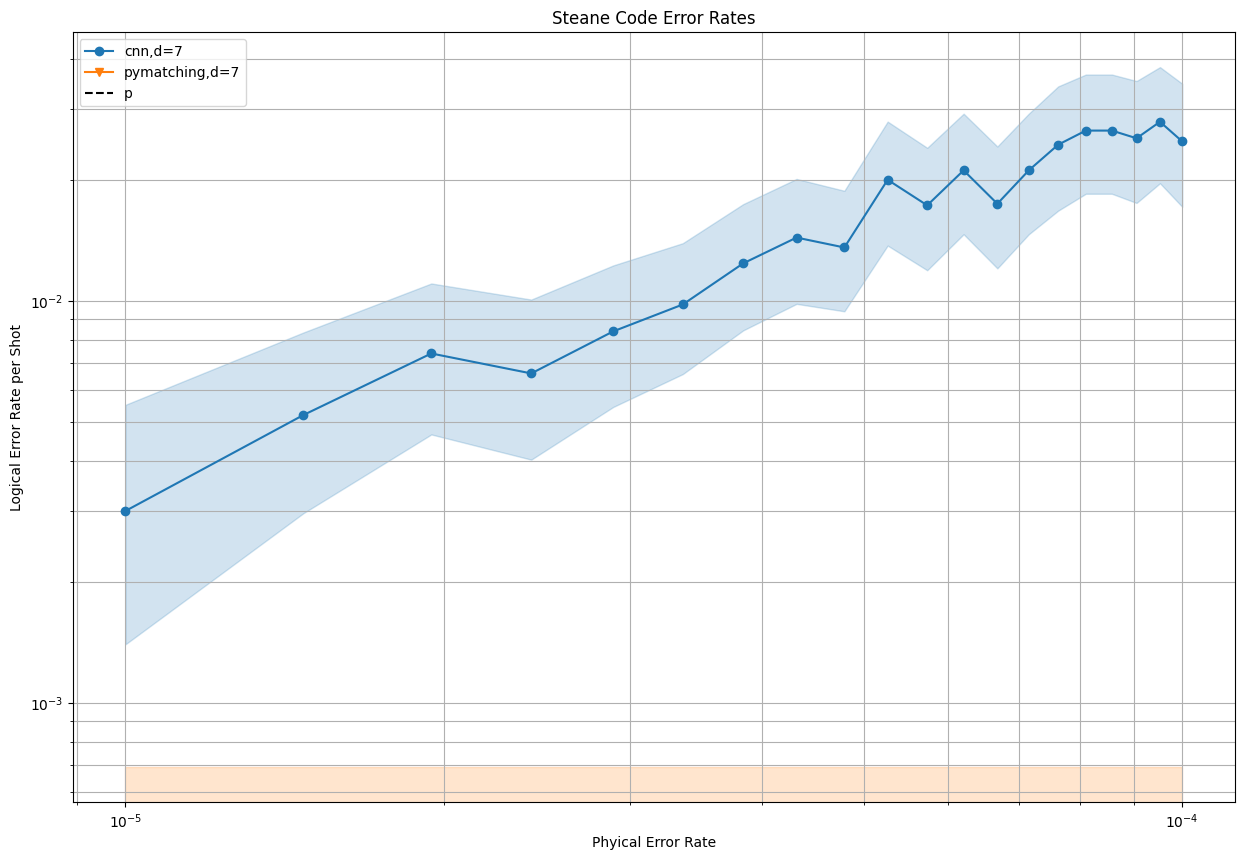

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(15,10))
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: f"{stats.decoder},d={stats.json_metadata['d']}",
)
ax.axline((0, 0), slope=1, label='p', linestyle='--', color='black')
ax.loglog()
ax.set_title("Steane Code Error Rates")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()

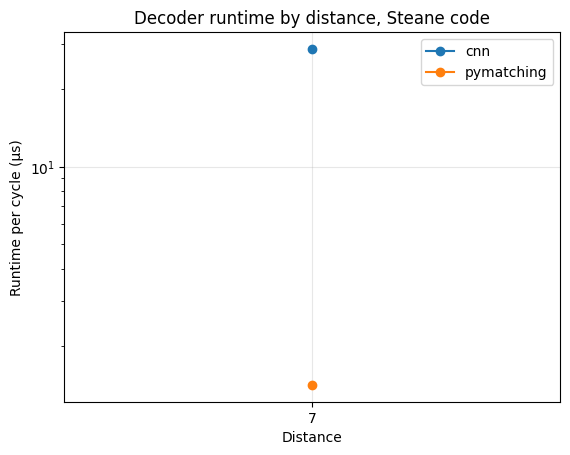

In [ ]:
decoders = ["cnn", "pymatching"]

for decoder in decoders:
    runtimes_us = []

    for d in distances:
        matching_stats = [
            stat for stat in collected_stats
            if stat.decoder == decoder
            and stat.json_metadata["d"] == d
        ]

        total_seconds = sum(stat.seconds for stat in matching_stats)
        total_shots = sum(stat.shots for stat in matching_stats)

        runtime_us = 1e6 * total_seconds / total_shots
        runtimes_us.append(runtime_us)

    plt.plot(distances, runtimes_us, marker='o', label=decoder)

plt.xlabel("Distance")
plt.ylabel("Runtime per cycle (μs)")
plt.title("Decoder runtime by distance, surface code")
plt.xticks(distances)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()